In [45]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
from math import atan2, asin
import cv2

# === Specify your episode folder ===
DATA_ROOT = Path("/nethome/rpunamiya6/flash/Projects/mecka_sample_data/684e17e77198b70c9d638dd3")

VIDEO_PATH = DATA_ROOT / "video.mp4"
FRAMES_CSV = DATA_ROOT / "frames.csv"
HANDS_CSV = DATA_ROOT / "hands.csv"
EGOMOTION_TXT = DATA_ROOT / "egomotion.txt"
ANNOTATIONS_CSV = DATA_ROOT / "annotations.csv"
INTRINSICS_JSON = DATA_ROOT / "intrinsics.json"

# Quick sanity check
for p in [VIDEO_PATH, FRAMES_CSV, HANDS_CSV, EGOMOTION_TXT, ANNOTATIONS_CSV, INTRINSICS_JSON]:
    if not p.exists():
        print(f"⚠️ Missing: {p.name}")
    else:
        print(f"✅ Found: {p.name}")

✅ Found: video.mp4
✅ Found: frames.csv
✅ Found: hands.csv
✅ Found: egomotion.txt
✅ Found: annotations.csv
✅ Found: intrinsics.json


In [46]:
with open(INTRINSICS_JSON, "r") as f:
    intrinsics = json.load(f)

# frames.csv
frames_df = pd.read_csv(FRAMES_CSV).sort_values("index").reset_index(drop=True)

# hands.csv
hands_raw = pd.read_csv(HANDS_CSV)
HAND_MAP = {0: "left_hand", 1: "right_hand"}

# group hands
hands_by_frame = {}
for (frame, hand_idx), grp in hands_raw.groupby(["frame", "hand_index"]):
    arr = np.full((21, 3), np.nan, dtype=np.float32)
    for _, row in grp.iterrows():
        li = int(row["landmark_index"])
        if 0 <= li < 21:
            arr[li] = [row["world_x"], row["world_y"], row["world_z"]]
    frame_dict = hands_by_frame.setdefault(int(frame), {})
    frame_dict[HAND_MAP.get(int(hand_idx), f"hand_{int(hand_idx)}")] = {"cam_landmarks": arr}


In [47]:
annotations_df = pd.read_csv(ANNOTATIONS_CSV)
frames_df["label"] = None
for i, row in frames_df.iterrows():
    ts = row["unix_timestamp"]
    match = annotations_df[(annotations_df["start_time"] <= ts) & (ts <= annotations_df["end_time"])]
    frames_df.at[i, "label"] = ";".join(match["Labels"].tolist()) if len(match) else None


In [48]:
ego_rows = []
with open(EGOMOTION_TXT, "r") as f:
    for line in f:
        line = line.strip()
        if not line or line.startswith("#"):
            continue
        parts = line.replace(",", " ").split()
        if len(parts) >= 11:
            frame = int(float(parts[0]))
            x, y, z = map(float, parts[1:4])
            yaw, pitch, roll = map(float, parts[4:7])
            qx, qy, qz, qw = map(float, parts[7:11])
            ego_rows.append({
                "frame": frame, "world_head_x": x, "world_head_y": y, "world_head_z": z,
                "yaw": yaw, "pitch": pitch, "roll": roll, "qx": qx, "qy": qy, "qz": qz, "qw": qw
            })

In [49]:
ego_df = pd.DataFrame(ego_rows)

In [50]:
# --- world_head_cartesian (10,) ---
head_pose_map = {
    int(r["frame"]): np.array([
        r["world_head_x"], r["world_head_y"], r["world_head_z"],
        r["yaw"], r["pitch"], r["roll"],
        r["qx"], r["qy"], r["qz"], r["qw"]
    ], dtype=np.float32)
    for _, r in ego_df.iterrows()
}

# --- world_wrist_xyz (6,) and world_hand_landmarks (21, 6) ---
hand_pose_map = {}
wrist_map = {}

for frame_idx, frame_dict in hands_by_frame.items():
    left = frame_dict.get("left_hand", {}).get("cam_landmarks", np.full((21, 3), np.nan))
    right = frame_dict.get("right_hand", {}).get("cam_landmarks", np.full((21, 3), np.nan))
    combined = np.concatenate([left, right], axis=1)  # (21,6)
    hand_pose_map[int(frame_idx)] = combined
    lwrist, rwrist = left[0], right[0]
    wrist_map[int(frame_idx)] = np.concatenate([lwrist, rwrist]).astype(np.float32)

# --- Merge into frames_df ---
frames_df["world_head_cartesian"] = frames_df["index"].apply(lambda i: head_pose_map.get(int(i), np.full(10, np.nan)))
frames_df["world_wrist_xyz"] = frames_df["index"].apply(lambda i: wrist_map.get(int(i), np.full(6, np.nan)))
frames_df["cam_hand_landmarks"] = frames_df["index"].apply(lambda i: hand_pose_map.get(int(i), np.full((21, 6), np.nan)))

frames_df.head(3)

,index,unix_timestamp,label,world_head_cartesian,world_wrist_xyz,cam_hand_landmarks
0,0,1.749923e+09,None,"[-0.169162, 0.000622, 1.74485, 0.198681, 1.156...","[0.58218217, -0.0012197043, -0.20294656, 0.528...","[[0.58218217, -0.0012197043, -0.20294656, 0.52..."
1,1,1.749923e+09,None,"[-0.163643, -0.000416, 1.74006, 0.207673, 1.16...","[0.58471185, -9.479034e-05, -0.20338227, 0.533...","[[0.58471185, -9.479034e-05, -0.20338227, 0.53..."
2,2,1.749923e+09,None,"[-0.158526, -0.001591, 1.735752, 0.216946, 1.1...","[0.5867673, 0.0014248817, -0.203797, 0.5370947...","[[0.5867673, 0.0014248817, -0.203797, 0.537094..."


In [51]:
f = int(frames_df.iloc[0]["index"])
print("Frame:", f)
print("world_head_cartesian:", frames_df.loc[0, "world_head_cartesian"].shape)
print("world_wrist_xyz:", frames_df.loc[0, "world_wrist_xyz"].shape)
print("cam_hand_landmarks:", frames_df.loc[0, "cam_hand_landmarks"].shape)

Frame: 0
world_head_cartesian: (10,)
world_wrist_xyz: (6,)
cam_hand_landmarks: (21, 6)


In [66]:
def build_camera_matrix_and_distortion(intrinsics, video_path):
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise IOError(f"Cannot open video: {video_path}")
    vid_w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    vid_h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    cap.release()

    w0, h0 = float(intrinsics["w"]), float(intrinsics["h"])
    fx0, fy0 = float(intrinsics["fl_x"]), float(intrinsics["fl_y"])
    cx0, cy0 = float(intrinsics["cx"]),  float(intrinsics["cy"])
    k1 = float(intrinsics.get("k1", 0.0))
    k2 = float(intrinsics.get("k2", 0.0))
    p1 = float(intrinsics.get("p1", 0.0))
    p2 = float(intrinsics.get("p2", 0.0))

    sx = vid_w / w0
    sy = vid_h / h0
    fx, fy = fx0 * sx, fy0 * sy
    cx, cy = cx0 * sx, cy0 * sy

    K = np.array([[fx, 0.0, cx],
                  [0.0, fy, cy],
                  [0.0, 0.0, 1.0]], dtype=np.float64)
    distCoeffs = np.array([k1, k2, p1, p2, 0.0], dtype=np.float64)  # k3=0
    return K, distCoeffs, (vid_w, vid_h)

K, distCoeffs, (VID_W, VID_H) = build_camera_matrix_and_distortion(intrinsics, VIDEO_PATH)

# 2) Correct Mecka→OpenCV camera-frame conversion:
# Mecka:  X fwd,  Y left,  Z up
# OpenCV: X right, Y down, Z fwd
# => [X_cv, Y_cv, Z_cv] = [-Y_m, -Z_m, X_m]
def mecka_to_opencv(points_cam_mecka):
    pts = np.asarray(points_cam_mecka, dtype=np.float64)
    if pts.ndim != 2 or pts.shape[1] != 3:
        raise ValueError("points_cam_mecka must be (N,3)")
    Xm, Ym, Zm = pts[:, 0], pts[:, 1], pts[:, 2]
    Xcv = -Ym
    Ycv = -Zm
    Zcv =  Xm
    return np.stack([Xcv, Ycv, Zcv], axis=1)

# 3) Extract (21,6) landmarks → (42,3) in Mecka cam frame
def get_hand_points_cam(frame_row):
    arr = frame_row.get("cam_hand_landmarks", None)
    if not isinstance(arr, np.ndarray) or arr.shape != (21, 6):
        return np.empty((0, 3), dtype=np.float64)
    left  = arr[:, 0:3]
    right = arr[:, 3:6]
    pts = np.vstack([left, right]).astype(np.float64)  # (42,3)
    return pts[np.isfinite(pts).all(axis=1)]

# 4) Project one frame’s landmarks
def project_mecka_points_single_t(frame_idx, clip_to_image=True, debug=False):
    fr = frames_df.loc[frames_df["index"] == int(frame_idx)]
    if fr.empty:
        raise ValueError(f"No frames_df row for frame {frame_idx}")
    row = fr.iloc[0]

    # (42,3) in Mecka cam frame → OpenCV cam frame
    pts_cam_mecka = get_hand_points_cam(row)
    if pts_cam_mecka.size == 0:
        return np.zeros((0,2)), np.zeros((0,), bool), np.zeros((0,3))
    pts_cam_cv = mecka_to_opencv(pts_cam_mecka)

    # Depth filter (OpenCV expects Z forward)
    z = pts_cam_cv[:, 2]
    z_pos = z > 0
    pts_cam_cv = pts_cam_cv[z_pos]
    if pts_cam_cv.size == 0:
        if debug: print("All points behind camera (Z<=0).")
        return np.zeros((0,2)), np.zeros((0,), bool), np.zeros((0,3))

    # Project (rvec=tvec=0 because points already in camera coords)
    obj = pts_cam_cv.reshape(-1, 1, 3)
    rvec = np.zeros((3, 1), dtype=np.float64)
    tvec = np.zeros((3, 1), dtype=np.float64)
    img_pts, _ = cv2.projectPoints(obj, rvec, tvec, K, distCoeffs)
    img_pts = img_pts.reshape(-1, 2)
    
    # print(img_pts)

    if debug:
        print(f"Z range: [{z[z_pos].min():.4f}, {z[z_pos].max():.4f}]")
        print(f"Pixels x:[{img_pts[:,0].min():.1f},{img_pts[:,0].max():.1f}] y:[{img_pts[:,1].min():.1f},{img_pts[:,1].max():.1f}]")

    if clip_to_image:
        in_bounds = (
            (img_pts[:,0] >= 0) & (img_pts[:,0] < VID_W) &
            (img_pts[:,1] >= 0) & (img_pts[:,1] < VID_H)
        )
    else:
        in_bounds = np.ones(len(img_pts), dtype=bool)
    return img_pts, in_bounds, pts_cam_cv

# 5) Read a video frame + visualize overlays
def read_frame_rgb(video_path, frame_idx):
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise IOError(f"Cannot open video: {video_path}")
    cap.set(cv2.CAP_PROP_POS_FRAMES, int(frame_idx))
    ok, frame = cap.read(); cap.release()
    if not ok:
        raise IOError(f"Failed to read frame {frame_idx}")
    return cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

def visualize_mecka_projection_single_t(frame_idx, point_size=20, alpha=0.85, debug=False):
    # Project hand points
    img_pts, mask, _ = project_mecka_points_single_t(frame_idx, clip_to_image=True, debug=debug)
    img = read_frame_rgb(VIDEO_PATH, frame_idx)

    plt.figure(figsize=(10, 5.625))
    plt.imshow(img)
    plt.axis("off")

    if img_pts.size:
        n = img_pts.shape[0]
        nL = min(21, n)
        L = np.arange(nL, dtype=int)
        R = np.arange(21, min(42, n), dtype=int)

        # Left hand (purple)
        if n >= nL:
            Lm = L[mask[L]]
            plt.scatter(
                img_pts[Lm, 0],
                img_pts[Lm, 1],
                s=point_size,
                c="mediumorchid",
                edgecolors="white",
                linewidths=0.4,
                alpha=alpha,
                label="Left hand (purple)",
            )

        # Right hand (orange)
        if n > 21:
            Rm = R[mask[R]]
            plt.scatter(
                img_pts[Rm, 0],
                img_pts[Rm, 1],
                s=point_size,
                c="orange",
                edgecolors="black",
                linewidths=0.4,
                alpha=alpha,
                label="Right hand (orange)",
            )

    # Optional frame label
    fr = frames_df.loc[frames_df["index"] == int(frame_idx)]
    if not fr.empty:
        lab = fr.iloc[0].get("label", None)
        if isinstance(lab, str) and lab:
            plt.text(
                10,
                25,
                f"Label: {lab}",
                color="yellow",
                fontsize=10,
                bbox=dict(facecolor="black", alpha=0.35, pad=3),
            )

    plt.legend(loc="lower right", fontsize=8, frameon=False)
    plt.tight_layout()
    plt.show()


Z range: [0.6125, 0.9162]
Pixels x:[914.7,1231.8] y:[568.6,831.6]


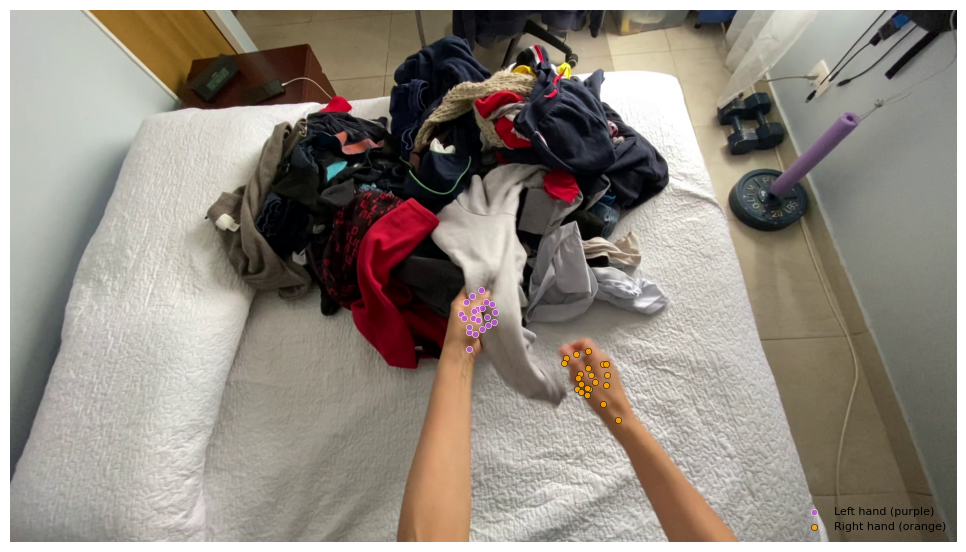

In [67]:
t = int(frames_df.iloc[100]["index"])
visualize_mecka_projection_single_t(t, debug=True)

In [ ]:
import torch
from torchvision.io import write_video

frames_out = []

left_color  = (186, 85, 211)   # purple
right_color = (255, 165, 0)    # orange
outline_color = (255, 255, 255)

cap = cv2.VideoCapture(str(VIDEO_PATH))
fps = cap.get(cv2.CAP_PROP_FPS) or 30
cap.release()

for t in frames_df["index"].astype(int):
    img = read_frame_rgb(VIDEO_PATH, t)
    img_bgr = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)

    img_pts, mask, _ = project_mecka_points_single_t(t, clip_to_image=True, debug=False)

    if img_pts.size > 0:
        n = img_pts.shape[0]
        nL = min(21, n)
        L = np.arange(nL, dtype=int)
        R = np.arange(21, min(42, n), dtype=int)

        def draw_point(img, x, y, fill_color):
            cv2.circle(img, (int(x), int(y)), 6, outline_color, thickness=2, lineType=cv2.LINE_AA)
            cv2.circle(img, (int(x), int(y)), 4, fill_color, thickness=-1, lineType=cv2.LINE_AA)

        # left hand (purple)
        for i in L[mask[L]]:
            x, y = img_pts[i]
            draw_point(img_bgr, x, y, left_color)

        # right hand (orange)
        if n > 21:
            for i in R[mask[R]]:
                x, y = img_pts[i]
                draw_point(img_bgr, x, y, right_color)

    frame_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    frames_out.append(torch.from_numpy(frame_rgb).to(torch.uint8))

video_tensor = torch.stack(frames_out, dim=0)  # (T, H, W, 3)
write_video(
    filename="./mecka_overlay.mp4",
    video_array=video_tensor,
    fps=fps,
    video_codec="h264",
    options={"crf": "18", "preset": "medium"},
)

print(f"✅ saved video with {video_tensor.shape[0]} frames @ {fps:.1f} fps → mecka_overlay.mp4")